<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Juan Pablo Sanchez Luis
-
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [1]:
### TU CÓDIGO AQUÍ ###
# Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para Machine Learning (Clustering)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Para evitar mensajes de advertencia innecesarios
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [4]:
### TU CÓDIGO AQUÍ ###
url = 'https://raw.githubusercontent.com/LinaMariaCastro/curso-ia-para-economia/main/datasets/Country-data.csv'
df = pd.read_csv(url)

2. Muestra las 5 primeras filas

In [6]:
print("Primeras 5 filas:")
### TU CÓDIGO AQUÍ ###
df.head()

Primeras 5 filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [7]:
print("\nInformación del DataFrame:")
### TU CÓDIGO AQUÍ ###
df.info()
# Adicionalmente para ver valores faltantes específicos:
print("\nValores faltantes por columna:")
print(df.isnull().sum())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Valores faltantes por columna:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


4. Obtén las estadísticas descriptivas de las variables del dataset

In [8]:
print("\nEstadísticas Descriptivas:")
### TU CÓDIGO AQUÍ ###
df.describe()


Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

No, el dataset está limpio. Al ejecutar df.info() o df.isnull().sum(), observamos que todas las columnas tienen 167 registros no nulos. Esto es positivo para el modelo, ya que no necesitamos aplicar técnicas de imputación o eliminar filas que podrían sesgar los grupos.

6. ¿Las escalas de las variables son muy diferentes?}

Sí, las escalas son extremadamente heterogéneas.

Por un lado, tenemos variables porcentuales o de tasas pequeñas como inflation (máximo de 104) o total_fer (máximo de 7.49).

Por otro lado, tenemos variables monetarias como income (máximo de 125,000) y gdpp (máximo de 105,000).

Conclusión: La diferencia de magnitud entre el PIB y la inflación es de casi 1,000 a 1.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?

Como economista, esta es la parte clave. El algoritmo K-Means calcula la similitud entre países usando distancias euclidianas.

Si no corregimos las escalas, el algoritmo le dará un peso desproporcionado a las variables con números grandes (PIB e Ingreso).

Básicamente, el modelo ignoraría indicadores sociales vitales (como la mortalidad infantil) solo porque sus valores numéricos son pequeños.

Solución necesaria: Es obligatorio realizar un escalamiento o normalización (usando StandardScaler) para que todas las variables tengan una media de 0 y una desviación estándar de 1 antes de entrenar el modelo.

8. Redacta un análisis de las estadísticas descriptivas

El dataset revela una profunda brecha socioeconómica global. El PIB per cápita (gdpp) presenta una desviación estándar de 18,328, valor superior a su propia media (12,964), lo que indica una dispersión extrema y la presencia de países con ingresos atípicos. Mientras que el 50% de los países sobrevive con un ingreso anual inferior a 9,960, existen naciones que alcanzan los 125,000, sugiriendo que el clustering identificará claramente un grupo de economías de élite frente a una mayoría en desarrollo. Asimismo, la mortalidad infantil muestra casos críticos de hasta 208 por cada mil nacidos, lo que permite prever que las condiciones de salud serán un factor determinante en la segmentación de los grupos.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [9]:
### TU CÓDIGO AQUÍ ###
# Eliminamos la columna 'country' para el análisis
df_numeric = df.drop('country', axis=1)

2. Estandariza las variables usando StandardScaler

In [10]:
### TU CÓDIGO AQUÍ ###
# Inicializamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos los datos
df_scaled = scaler.fit_transform(df_numeric)

# Lo convertimos de nuevo a un DataFrame para que sea fácil de leer
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

# Mostramos las primeras filas para verificar
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

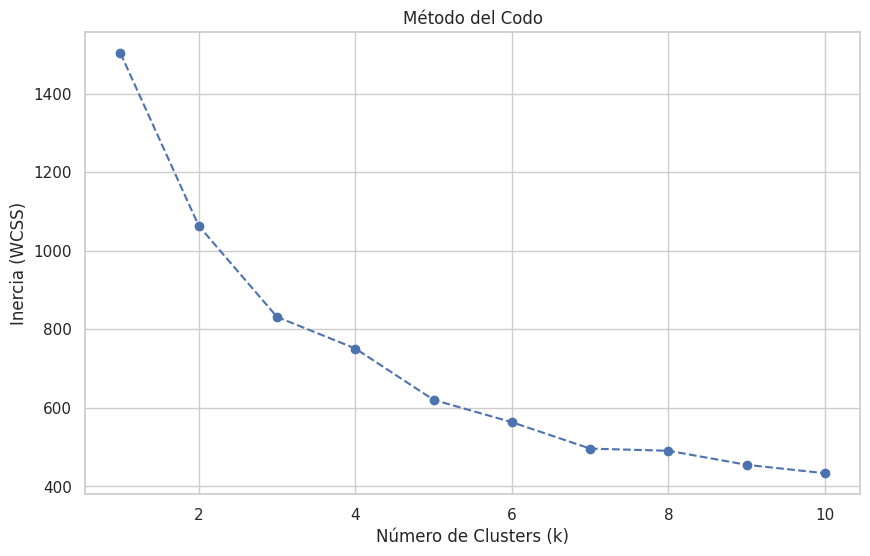

In [11]:
### TU CÓDIGO AQUÍ ###
# Lista para guardar los valores de inercia
wcss = []

# Probamos k del 1 al 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Graficamos el Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.show()

2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

Observando tu gráfica del Método del Codo, se nota un cambio de pendiente importante en k=3.

Hasta $k=3$ la inercia (WCSS) cae de manera muy pronunciada. A partir de ese punto, la ganancia en "explicación" de los datos por cada cluster adicional empieza a ser menor (rendimientos marginales decrecientes). Por lo tanto, 3 clusters parece ser el número adecuado bajo este criterio.

3. Calcula y grafica el coeficiente de silueta

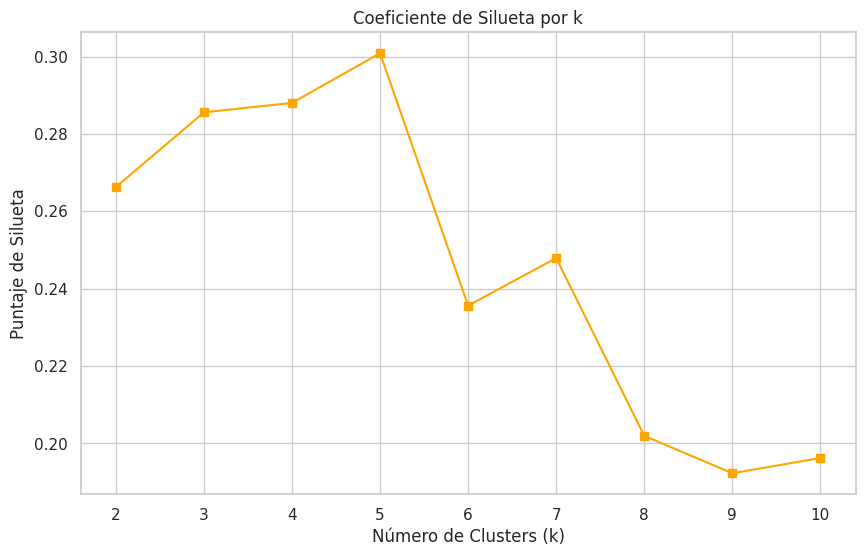

In [12]:
# Lista para los puntajes de silueta
sil_scores = []

# Probamos k del 2 al 10 (la silueta no funciona con k=1)
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, cluster_labels))

# Graficamos los puntajes de Silueta
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_scores, marker='s', color='orange')
plt.title('Coeficiente de Silueta por k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntaje de Silueta')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

Mirando tu gráfica de Coeficiente de Silueta, el pico más alto (el puntaje máximo) ocurre en k=5 (con un valor de aproximadamente $0.30$).

El coeficiente de silueta mide qué tan bien separado está cada cluster de sus vecinos. Según esta métrica, 5 clusters ofrecen la mejor estructura de separación y cohesión para este conjunto de datos.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

Elegimos k=3.

Aunque el coeficiente de silueta sugiere que 5 grupos están más separados matemáticamente, el Método del Codo muestra que 3 grupos ya capturan la mayor parte de la varianza. Desde una perspectiva de política pública y economía, es más interpretable y eficiente clasificar a los países en tres grandes categorías (ej: Ingresos Bajos/En Desarrollo, Ingresos Medios y Economías Avanzadas) que fragmentarlos en 5 grupos que podrían tener diferencias menos significativas entre sí.

6. Aplica K-Means con el k que tu grupo eligió.

In [13]:
### TU CÓDIGO AQUÍ ###
# Entrenamos el modelo con k=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(df_scaled)

7. Añade la asignación de clusters al DataFrame original

In [14]:
### TU CÓDIGO AQUÍ ###
# Añadimos la columna al DataFrame original
df['Cluster'] = clusters

# Vemos las primeras filas con su nueva etiqueta
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,2
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,2
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [18]:
### TU CÓDIGO AQUÍ ###
# Agrupamos por cluster y calculamos la media solo de las columnas numéricas
perfil_clusters = df.groupby('Cluster').mean(numeric_only=True)
perfil_clusters

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,"12,321.74",7.72,72.57,2.34,"6,461.77"
1,5.00,58.74,8.81,51.49,"45,672.22",2.67,80.13,1.75,"42,494.44"
2,95.11,28.60,6.30,42.31,"3,539.84",11.99,59.06,5.07,"1,766.71"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

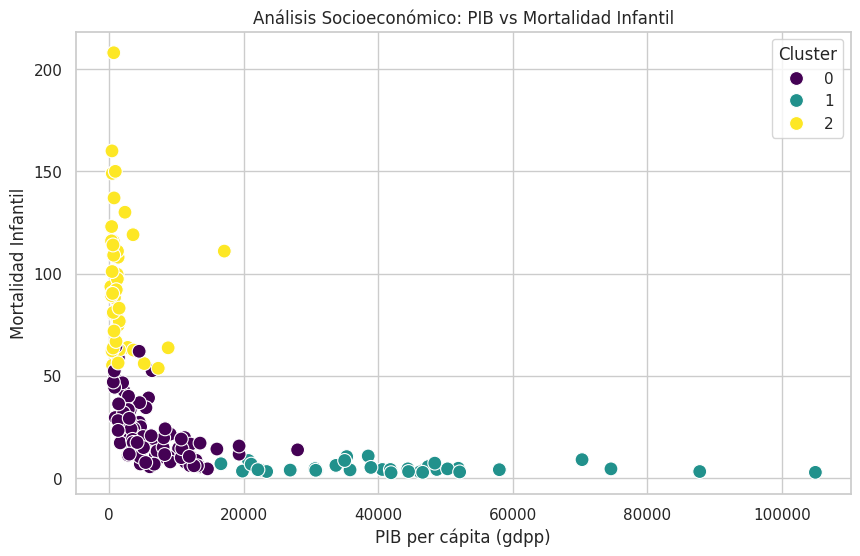

In [19]:
### TU CÓDIGO AQUÍ ###
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster', palette='viridis', s=100)
plt.title('Análisis Socioeconómico: PIB vs Mortalidad Infantil')
plt.xlabel('PIB per cápita (gdpp)')
plt.ylabel('Mortalidad Infantil')
plt.legend(title='Cluster')
plt.show()

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.

Cluster 2 (Amarillo): Países con Bajos Ingresos / Prioridad Humanitaria.

Cluster 0 (Morado): Economías Emergentes / Desarrollo Medio.

Cluster 1 (Verde): Economías Avanzadas / Altos Ingresos.

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.

Cluster 2 (Amarillo): Se agrupan en la parte superior izquierda. Tienen el PIB per cápita más bajo y las tasas de mortalidad infantil más altas (muchos por encima de 100). Son países con graves carencias en infraestructura de salud y servicios básicos.

Cluster 0 (Morado): Es el grupo más numeroso. Muestran un avance significativo en salud (mortalidad mucho más baja que el grupo amarillo) pero sus ingresos aún son moderados (están "estancados" en la parte baja del eje X). Aquí es donde suelen clasificarse la mayoría de países latinoamericanos.

Cluster 1 (Verde): Son los puntos extendidos hacia la derecha del eje X. Tienen ingresos altísimos y una mortalidad infantil casi nula. La brecha económica con los otros grupos es abismal.


5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

Para los países del Cluster 2, se recomienda que el PNUD implemente programas de transferencias tecnológicas para sistemas de salud primaria y saneamiento de agua. Dado que presentan niveles de mortalidad infantil críticos con ingresos muy limitados, la ayuda externa no solo debe ser financiera, sino enfocada en reducir la brecha de salud básica, que es el principal freno para su desarrollo productivo a largo plazo.